# Problem 2b: Simulation of Outlier Sensitivity in Linear Regression

We simulate a simple linear regression model and then add one extreme observation to study how the estimated regression line changes.

We compare:

- a **clean sample** with no artificial extreme point,
- a **contaminated sample** with one added extreme point.

The purpose is to show that OLS estimates can be sensitive to unusual observations.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.precision", 6)

We use:

- `numpy` for simulation,
- `pandas` for organizing the data and results,
- `matplotlib` for visualization,
- `statsmodels` for OLS estimation and influence diagnostics.

In [2]:
# Baseline simulation settings
alpha_true = 1.0
beta_true = 3.0
sigma = 1.0

n = 30
seed = 42

We define the true data-generating process as

$$
Y_i = \alpha + \beta X_i + \varepsilon_i
$$

with

$$
\alpha = 1
\qquad \text{and} \qquad
\beta = 3.
$$

So the true slope is

$$
\beta = 3.
$$

The disturbance term is simulated independently so that the clean sample follows a standard simple linear regression design.

In [3]:
def simulate_clean_sample(n, seed, alpha, beta, sigma):
    rng = np.random.default_rng(seed)

    X = rng.uniform(0, 5, n)
    e = rng.normal(0, sigma, n)
    Y = alpha + beta * X + e

    df = pd.DataFrame({"X": X, "Y": Y})
    return df

The clean sample is generated from

$$
X_i \sim \operatorname{Uniform}(0,5),
\qquad
\varepsilon_i \sim N(0,\sigma^2),
$$

and

$$
Y_i = \alpha + \beta X_i + \varepsilon_i.
$$

This gives a benchmark dataset in which the fitted OLS line should be close to the true regression line.

In [6]:
def fit_simple_ols(df):
    X_reg = sm.add_constant(df["X"])
    model = sm.OLS(df["Y"], X_reg).fit()
    return model

We estimate the regression

$$
Y_i = \hat{\alpha} + \hat{\beta} X_i + \hat{\varepsilon}_i
$$

using OLS.

The estimated intercept and slope from the clean sample will be the baseline results.

In [7]:
# Generate clean sample and fit baseline regression
df_clean = simulate_clean_sample(
    n=n,
    seed=seed,
    alpha=alpha_true,
    beta=beta_true,
    sigma=sigma
)

model_clean = fit_simple_ols(df_clean)

print("=== Clean sample regression ===")
print(model_clean.summary())

=== Clean sample regression ===
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.968
Model:                            OLS   Adj. R-squared:                  0.966
Method:                 Least Squares   F-statistic:                     837.6
Date:                Sun, 05 Apr 2026   Prob (F-statistic):           2.08e-22
Time:                        12:23:58   Log-Likelihood:                -35.498
No. Observations:                  30   AIC:                             75.00
Df Residuals:                      28   BIC:                             77.80
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.196

This regression is the benchmark model.

Its coefficient estimates should be reasonably close to the true parameters:

$$
\alpha = 1,
\qquad
\beta = 3.
$$

In [8]:
# Add one influential leverage point
x_extreme = 8.0
y_extreme = 5.0

df_contaminated = pd.concat(
    [
        df_clean,
        pd.DataFrame({"X": [x_extreme], "Y": [y_extreme]})
    ],
    ignore_index=True
)

model_contaminated = fit_simple_ols(df_contaminated)

print("=== Contaminated sample regression ===")
print(model_contaminated.summary())

=== Contaminated sample regression ===
                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.513
Model:                            OLS   Adj. R-squared:                  0.496
Method:                 Least Squares   F-statistic:                     30.52
Date:                Sun, 05 Apr 2026   Prob (F-statistic):           5.92e-06
Time:                        12:25:12   Log-Likelihood:                -78.729
No. Observations:                  31   AIC:                             161.5
Df Residuals:                      29   BIC:                             164.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        

We now add one manually chosen extreme point:

$$
\left(X_{\text{new}},\, Y_{\text{new}}\right) = (8,\,5).
$$

This point lies far to the right of the original sample and does not follow the original positive linear trend.

So it is designed to act as an **influential leverage point**.

In [9]:
# Compare coefficient estimates
comparison = pd.DataFrame({
    "Quantity": [
        "True intercept",
        "Estimated intercept (clean sample)",
        "Estimated intercept (contaminated sample)",
        "True slope",
        "Estimated slope (clean sample)",
        "Estimated slope (contaminated sample)"
    ],
    "Value": [
        alpha_true,
        model_clean.params["const"],
        model_contaminated.params["const"],
        beta_true,
        model_clean.params["X"],
        model_contaminated.params["X"]
    ]
})

comparison

,Quantity,Value
0,True intercept,1.000000
1,Estimated intercept (clean sample),1.196146
2,Estimated intercept (contaminated sample),3.873965
3,True slope,3.000000
4,Estimated slope (clean sample),2.970530
5,Estimated slope (contaminated sample),1.849687


The key numerical comparison is between:

- the clean-sample estimates,
- the contaminated-sample estimates.

If the added point is influential, then both the estimated intercept and slope will shift noticeably after contamination.

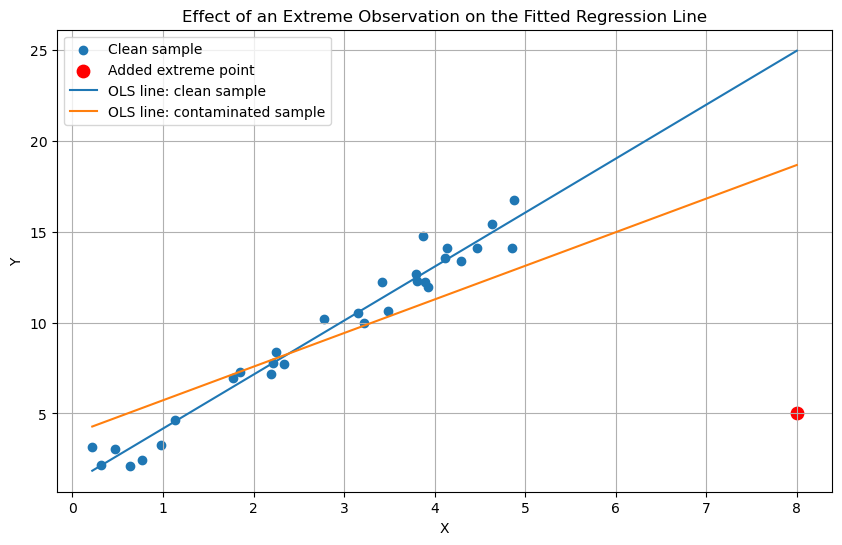

In [10]:
# Plot both regression lines
x_grid = np.linspace(df_contaminated["X"].min(), df_contaminated["X"].max(), 200)

y_clean_fit = model_clean.params["const"] + model_clean.params["X"] * x_grid
y_cont_fit = model_contaminated.params["const"] + model_contaminated.params["X"] * x_grid

plt.scatter(df_clean["X"], df_clean["Y"], label="Clean sample")
plt.scatter(x_extreme, y_extreme, color="red", s=80, label="Added extreme point")

plt.plot(x_grid, y_clean_fit, label="OLS line: clean sample")
plt.plot(x_grid, y_cont_fit, label="OLS line: contaminated sample")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Effect of an Extreme Observation on the Fitted Regression Line")
plt.legend()
plt.grid(True)
plt.show()

This plot gives the main visual result.

We compare:

- the OLS line from the clean sample,
- the OLS line after adding the extreme point.

A large change in the line indicates that the added observation is influential.

In [11]:
# Influence diagnostics for contaminated model
influence = model_contaminated.get_influence()
influence_df = influence.summary_frame()

# Add row labels
influence_df = influence_df.reset_index().rename(columns={"index": "Observation"})
influence_df.sort_values("cooks_d", ascending=False).head(10)

,Observation,dfb_const,dfb_X,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
30,30,9.075752,-12.980566,6.241774,-5.209406,0.315070,-3.533206,-20.200750,-13.700874
5,5,-0.114271,0.268846,0.063270,1.266452,0.073126,0.355724,1.280334,0.359624
8,8,-0.310707,0.252240,0.048937,-0.980348,0.092424,-0.312847,-0.979667,-0.312630
28,28,-0.284922,0.227292,0.041553,-0.940791,0.085836,-0.288281,-0.938866,-0.287691
17,17,-0.266359,0.224306,0.036094,-0.763351,0.110230,-0.268680,-0.757725,-0.266700
11,11,-0.064132,0.177968,0.032312,0.977384,0.063362,0.254211,0.976604,0.254008
0,0,0.007912,0.117994,0.030998,1.197908,0.041414,0.248990,1.207323,0.250947
25,25,-0.220518,0.170587,0.025521,-0.785362,0.076428,-0.225923,-0.780042,-0.224393
4,4,-0.189113,0.156683,0.018423,-0.571010,0.101535,-0.191956,-0.564259,-0.189686
18,18,-0.015340,0.104761,0.017185,0.828904,0.047640,0.185392,0.824311,0.184365


To diagnose the extreme point formally, we compute influence measures from the contaminated regression.

The most useful quantities here are:

- leverage,
- studentized residuals,
- Cook's distance.

These help us determine whether the added point is merely unusual or truly influential.

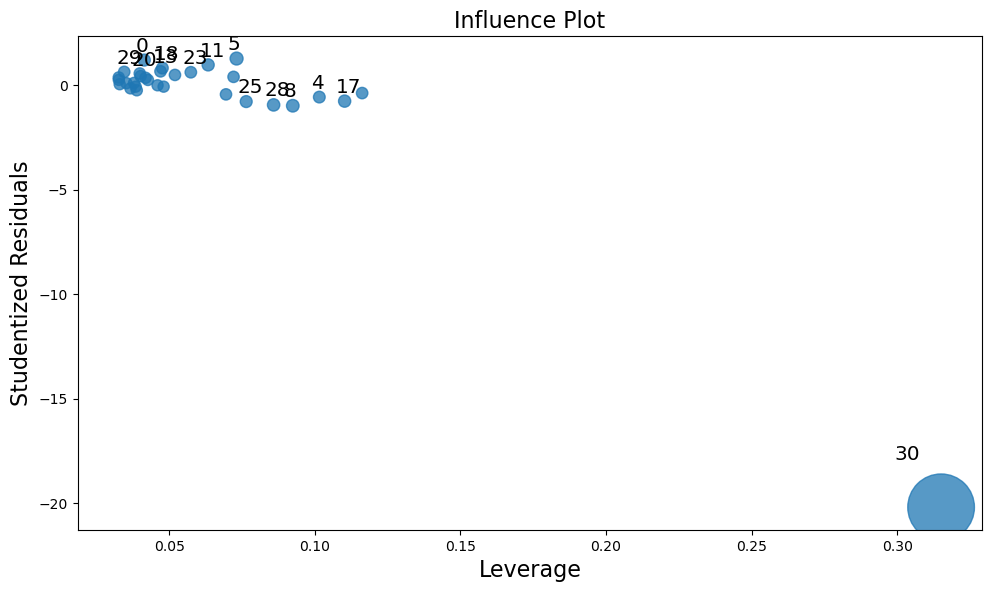

In [12]:
# Influence plot
fig = sm.graphics.influence_plot(model_contaminated, criterion="cooks", alpha=0.6)
fig.tight_layout(pad=1.0)
plt.show()

The influence plot combines:

- leverage on the horizontal axis,
- studentized residuals on the vertical axis,
- Cook's distance through bubble size.

A point with large leverage and a large residual typically has a high Cook's distance and can substantially affect the fitted model.

In [13]:
# Display the most influential observations
top_influential = influence_df.sort_values("cooks_d", ascending=False)[
    ["Observation", "hat_diag", "student_resid", "cooks_d"]
].head(10)

top_influential

,Observation,hat_diag,student_resid,cooks_d
30,30,0.315070,-20.200750,6.241774
5,5,0.073126,1.280334,0.063270
8,8,0.092424,-0.979667,0.048937
28,28,0.085836,-0.938866,0.041553
17,17,0.110230,-0.757725,0.036094
11,11,0.063362,0.976604,0.032312
0,0,0.041414,1.207323,0.030998
25,25,0.076428,-0.780042,0.025521
4,4,0.101535,-0.564259,0.018423
18,18,0.047640,0.824311,0.017185


This table identifies the observations with the largest Cook's distance.

If the added extreme point appears near the top of the list, then the simulation confirms that it is one of the most influential observations in the sample.

In [14]:
# Quantify the coefficient changes
delta_intercept = model_contaminated.params["const"] - model_clean.params["const"]
delta_slope = model_contaminated.params["X"] - model_clean.params["X"]

print("Change in intercept:", round(delta_intercept, 6))
print("Change in slope:", round(delta_slope, 6))

Change in intercept: 2.677818
Change in slope: -1.120843


We measure the effect of contamination numerically as

$$
\Delta \hat{\alpha}
=
\hat{\alpha}_{\text{contaminated}}
-
\hat{\alpha}_{\text{clean}},
$$

and

$$
\Delta \hat{\beta}
=
\hat{\beta}_{\text{contaminated}}
-
\hat{\beta}_{\text{clean}}.
$$

These values summarize how much the added extreme point changed the estimated regression parameters.

## Conclusion

We simulated a clean sample from the linear model

$$
Y_i = \alpha + \beta X_i + \varepsilon_i
$$

and then added one extreme observation.

We found that:

- the fitted regression line changed after contamination,
- the estimated slope and intercept shifted,
- the influence diagnostics assigned high leverage and a large Cook's distance to the added point.

Therefore, the simulation shows that OLS regression can be sensitive to influential outliers, especially when a point has both unusual predictor values and a large deviation from the original trend.